# US older adults mobility decline

In [ ]:
# (1) Paths and dependencies
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.optimize import curve_fit

PROJECT_ROOT = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "global40.dta")
OUT_DIR = os.path.join(PROJECT_ROOT, "results", "f1b_scatter")
os.makedirs(OUT_DIR, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("OUT_DIR:", OUT_DIR)

In [7]:
# (2) Load & filter USA 840, age 40–100
d = pd.read_stata(DATA_PATH)

required_cols = {"isocountry", "ragey_b", "rwalkra", "rwalk1a", "rwalksa"}
if not required_cols.issubset(d.columns):
    missing = required_cols - set(d.columns)
    raise ValueError(f"Missing required columns: {missing}")
if not any(c in d.columns for c in ["wave", "riwendy", "wave_year"]):
    raise ValueError("Missing wave column: one of wave/riwendy/wave_year is required")

def pick_wave_id(df: pd.DataFrame) -> pd.Series:
    if "wave" in df.columns:
        return pd.to_numeric(df["wave"], errors="coerce")
    if "riwendy" in df.columns:
        return pd.to_numeric(df["riwendy"], errors="coerce")
    return pd.to_numeric(df["wave_year"], errors="coerce")

d = (
    d.loc[d["isocountry"] == 840].assign(
        age_int=np.floor(pd.to_numeric(d["ragey_b"], errors="coerce")),
        wave_id=pick_wave_id(d),
        rwalksa=pd.to_numeric(d["rwalksa"], errors="coerce"),
        rwalk1a=pd.to_numeric(d["rwalk1a"], errors="coerce"),
        rwalkra=pd.to_numeric(d["rwalkra"], errors="coerce"),
    )
    .loc[lambda x: x["age_int"].between(40, 100) & x["wave_id"].notna()]
    .dropna(subset=["age_int", "wave_id"])
)

print("USA rows:", d.shape[0])

USA rows: 294827


In [8]:
# (3) Ability (1 = no difficulty)
def to_cap(x: pd.Series) -> pd.Series:
    return np.where(x.isin([0, 1]), 1 - x, np.nan)

d = d.assign(
    capsa=to_cap(d["rwalksa"]),
    cap1a=to_cap(d["rwalk1a"]),
    capra=to_cap(d["rwalkra"]),
)

print("capsa/cap1a/capra prepared")

capsa/cap1a/capra prepared


In [9]:
# (4) Aggregate by age × wave × measure
long_df = (
    d.loc[:, ["age_int", "wave_id", "capsa", "cap1a", "capra"]]
    .melt(id_vars=["age_int", "wave_id"],
          value_vars=["capsa", "cap1a", "capra"],
          var_name="measure",
          value_name="ability")
    .assign(measure=lambda x: x["measure"].replace({
        "capsa": "rwalksa",
        "cap1a": "rwalk1a",
        "capra": "rwalkra",
    }))
    .dropna(subset=["ability"])
    .groupby(["age_int", "wave_id", "measure"], as_index=False)
    .agg(n=("ability", "size"), mean_prop=("ability", "mean"))
    .query("n >= 10")
)

sa = long_df.loc[long_df["measure"] == "rwalksa"].copy()
a1 = long_df.loc[long_df["measure"] == "rwalk1a"].copy()
ra = long_df.loc[long_df["measure"] == "rwalkra"].copy()

print("Aggregated rows:", long_df.shape[0])

Aggregated rows: 2737


Waves used: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0]


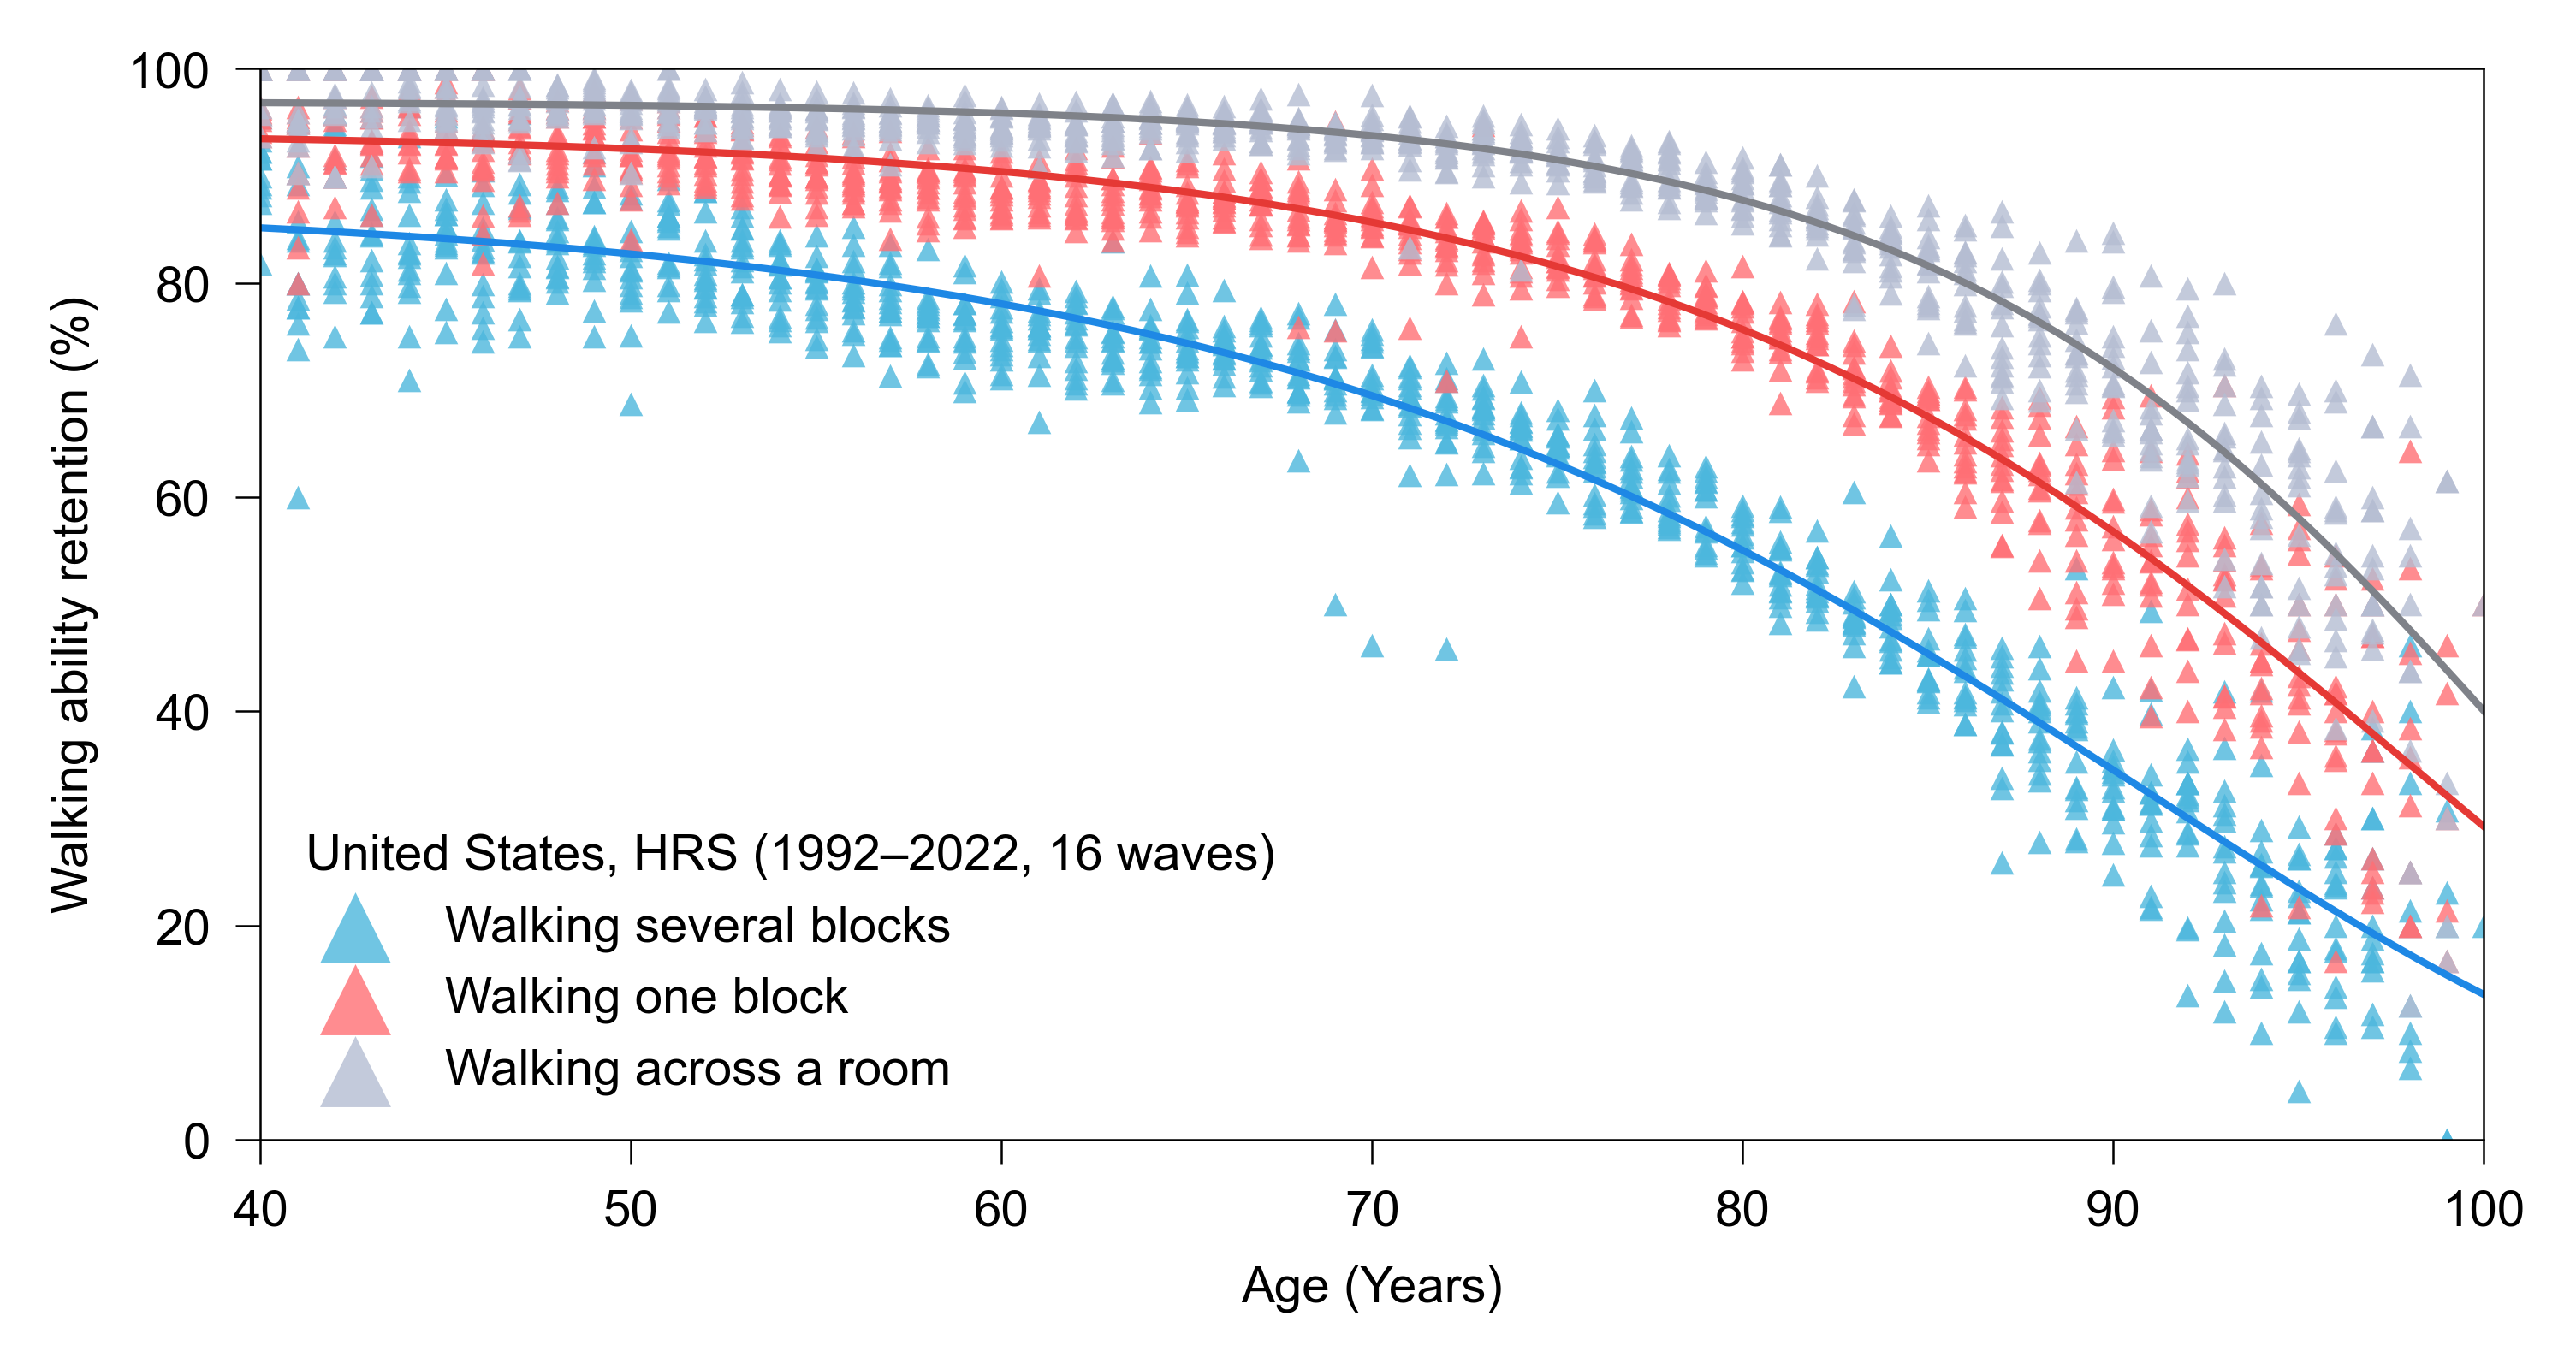

Saved: /Users/karwailin/Desktop/OAwalk/results/f1b_scatter/usa_scatter.pdf


In [10]:
# (5) Scatter and accelerating-decline fit ($y=a+b\,e^{c t}$)
T0 = 40

def gompertz(t, a, b, c):
    return a * np.exp(-b * np.exp(c * (t - T0)))

def fit_gompertz(df):
    x = df["age_int"].values.astype(float)
    y = df["mean_prop"].values.astype(float)
    if len(x) < 3:
        return None
    a0 = np.clip(np.nanmax(y), 0.2, 1.0)
    b0 = 0.05
    c0 = 0.03
    try:
        params, _ = curve_fit(
            gompertz,
            x,
            y,
            p0=[a0, b0, c0],
            bounds=([0.0, 1e-6, 1e-6], [1.0, 10.0, 1.0]),
            maxfev=20000,
        )
        return params
    except Exception:
        return None

def plot_fit(ax, df, color):
    params = fit_gompertz(df)
    if params is None:
        return
    xs = np.linspace(40, 100, 300)
    ys = gompertz(xs, *params)
    ax.plot(xs, ys, color=color, linewidth=1)

def scatter_by_wave(ax, df, color, label, wave_markers):
    first = True
    for wave_id, g in df.groupby("wave_id"):
        marker = wave_markers.get(wave_id, "o")
        ax.scatter(
            g["age_int"],
            g["mean_prop"],
            s=11,
            alpha=0.8,
            marker=marker,
            facecolors=color,
            edgecolors=color,
            linewidths=0,
            label=label if first else None,
        )
        first = False

plt.rcParams["font.family"] = "Arial"


fig, ax = plt.subplots(figsize=(13 / 2.54, 7 / 2.54), dpi=600)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

colors = {"rwalksa": "#4CB7DD", "rwalk1a": "#FF6F75", "rwalkra": "#B5BDD2"}
# colors = {"rwalksa": "#4E9FCF", "rwalk1a": "#E16164", "rwalkra": "#8793A9"}
# fit_colors = {"rwalksa": "#4E9FCF", "rwalk1a": "#E16164", "rwalkra": "#8793A9"}
fit_colors = {"rwalksa": "#1E88E5", "rwalk1a": "#E53935", "rwalkra": "#7F8289"}
labels = {
    "rwalksa": "Walking several blocks",
    "rwalk1a": "Walking one block",
    "rwalkra": "Walking across a room",
}

wave_ids = sorted(long_df["wave_id"].dropna().unique())
print("Waves used:", wave_ids)
marker_cycle = ["^"]
# marker_cycle = ["o", "s", "^", "v", "<", ">", "D", "d", "p", "h", "H", "8", "P", "X", "*", "+"]
wave_markers = {w: marker_cycle[i % len(marker_cycle)] for i, w in enumerate(wave_ids)}

scatter_by_wave(ax, sa, colors["rwalksa"], labels["rwalksa"], wave_markers)
scatter_by_wave(ax, a1, colors["rwalk1a"], labels["rwalk1a"], wave_markers)
scatter_by_wave(ax, ra, colors["rwalkra"], labels["rwalkra"], wave_markers)

plot_fit(ax, sa, fit_colors["rwalksa"]),
plot_fit(ax, a1, fit_colors["rwalk1a"]),
plot_fit(ax, ra, fit_colors["rwalkra"]),

ax.set_xlim(40, 100)
ax.set_ylim(0, 1)
ax.set_xticks(np.arange(40, 101, 10))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y * 100:.0f}"))
ax.set_xlabel("Age (Years)", fontsize=7)
ax.set_ylabel("Walking ability retention (%)", fontsize=7)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.3)
ax.tick_params(width=0.3, labelsize=7)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("normal")
ax.grid(False)

leg = ax.legend(
    loc="lower left",
    frameon=False,
    scatterpoints=1,
    numpoints=1,
    markerscale=3,
    fontsize=7,
    title="United States, HRS (1992–2022, 16 waves)",
    title_fontsize=7,
    prop={"weight": "normal", "size": 7},
)

leg.get_title().set_fontweight("normal")
leg._legend_box.align = "left"

out_path = os.path.join(OUT_DIR, "usa_scatter.pdf")
plt.tight_layout()
plt.savefig(out_path, dpi=600)
plt.show()
print("Saved:", out_path)